# Import Libraries

In [1]:
# import required packages
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch

from PIL import Image

import json
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from torch.nn.modules.loss import _Loss
from torch.autograd import Variable
from tqdm import tqdm

from sklearn.linear_model import LinearRegression

In [2]:
json_gt = [json.loads(line) for line in open('/kaggle/input/tusimple/test_label_new.json')]

In [3]:
import os
import subprocess
from IPython.display import FileLink, display

def download_file(path, download_file_name):
    os.chdir('/kaggle/working/')
    zip_name = f"/kaggle/working/{download_file_name}.zip"
    command = f"zip {zip_name} {path} -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print("Unable to run zip command!")
        print(result.stderr)
        return
    display(FileLink(f'{download_file_name}.zip'))

# Utils

In [ ]:
def split_path(path):
    """split path tree into list"""
    folders = []
    while True:
        path, folder = os.path.split(path)
        if folder != "":
            folders.insert(0, folder)
        else:
            if path != "":
                folders.insert(0, path)
            break
    return folders

def getLane_tusimple(prob_map, y_px_gap, pts, thresh, resize_shape=None):
    if resize_shape is None:
        resize_shape = prob_map.shape
    h, w = prob_map.shape
    H, W = resize_shape

    coords = np.zeros(pts)
    for i in range(pts):
        y = int((H - 10 - i * y_px_gap) * h / H)
        if y < 0:
            break
        line = prob_map[y, :]
        id = np.argmax(line)
        if line[id] > thresh:
            coords[i] = int(id / w * W)
    if (coords > 0).sum() < 2:
        coords = np.zeros(pts)
    return coords

def prob2lines_tusimple(seg_pred, exist, resize_shape=None, smooth=True, y_px_gap=10, pts=None, thresh=0.3):
    if resize_shape is None:
        resize_shape = seg_pred.shape[1:]  # seg_pred (5, h, w)
    _, h, w = seg_pred.shape
    H, W = resize_shape
    coordinates = []

    if pts is None:
        pts = round(H / 2 / y_px_gap)

    seg_pred = np.ascontiguousarray(np.transpose(seg_pred, (1, 2, 0)))
    for i in range(6):
        prob_map = seg_pred[..., i + 1]
        if smooth:
            prob_map = cv2.blur(prob_map, (9, 9), borderType=cv2.BORDER_REPLICATE)
        if exist[i] > 0:
            coords = getLane_tusimple(prob_map, y_px_gap, pts, thresh, resize_shape)
            coordinates.append(
                [[coords[j], H - 10 - j * y_px_gap] if coords[j] > 0 else [-1, H - 10 - j * y_px_gap] for j in
                 range(pts)])

    return coordinates

class LaneEval(object):
    lr = LinearRegression()
    pixel_thresh = 20
    pt_thresh = 0.85

    @staticmethod
    def get_angle(xs, y_samples):
        xs, ys = xs[xs >= 0], y_samples[xs >= 0]
        if len(xs) > 1:
            LaneEval.lr.fit(ys[:, None], xs)
            k = LaneEval.lr.coef_[0]
            theta = np.arctan(k)
        else:
            theta = 0
        return theta

    @staticmethod
    def line_accuracy(pred, gt, thresh):
        pred = np.array([p if p >= 0 else -100 for p in pred])
        gt = np.array([g if g >= 0 else -100 for g in gt])
        return np.sum(np.where(np.abs(pred - gt) < thresh, 1., 0.)) / len(gt)

    @staticmethod
    def bench(pred, gt, y_samples, running_time):
        if any(len(p) != len(y_samples) for p in pred):
            raise Exception('Format of lanes error.')
        if running_time > 200 or len(gt) + 2 < len(pred):
            return 0., 0., 1.
        angles = [LaneEval.get_angle(np.array(x_gts), np.array(y_samples)) for x_gts in gt]
        threshs = [LaneEval.pixel_thresh / np.cos(angle) for angle in angles]
        line_accs = []
        fp, fn = 0., 0.
        matched = 0.
        for x_gts, thresh in zip(gt, threshs):
            accs = [LaneEval.line_accuracy(np.array(x_preds), np.array(x_gts), thresh) for x_preds in pred]
            max_acc = np.max(accs) if len(accs) > 0 else 0.
            if max_acc < LaneEval.pt_thresh:
                fn += 1
            else:
                matched += 1
            line_accs.append(max_acc)
        fp = len(pred) - matched
        if len(gt) > 4 and fn > 0:
            fn -= 1
        s = sum(line_accs)
        if len(gt) > 4:
            s -= min(line_accs)
        return s / max(min(4.0, len(gt)), 1.), fp / len(pred) if len(pred) > 0 else 0., fn / max(min(len(gt), 4.) , 1.)

    @staticmethod
    def bench_one_submit(pred_file, gt_file):
        try:
            json_pred = [json.loads(line) for line in open(pred_file).readlines()]
        except BaseException as e:
            raise Exception('Fail to load json file of the prediction.')
        json_gt = [json.loads(line) for line in open(gt_file).readlines()]
        if len(json_gt) != len(json_pred):
            raise Exception('We do not get the predictions of all the test tasks')
        gts = {l['raw_file']: l for l in json_gt}
        accuracy, fp, fn = 0., 0., 0.
        for pred in json_pred:
            if 'raw_file' not in pred or 'lanes' not in pred or 'run_time' not in pred:
                raise Exception('raw_file or lanes or run_time not in some predictions.')
            raw_file = pred['raw_file']
            pred_lanes = pred['lanes']
            run_time = pred['run_time']
            if raw_file not in gts:
                raise Exception('Some raw_file from your predictions do not exist in the test tasks.')
            gt = gts[raw_file]
            gt_lanes = gt['lanes']
            y_samples = gt['h_samples']
            try:
                a, p, n = LaneEval.bench(pred_lanes, gt_lanes, y_samples, run_time)
            except BaseException as e:
                raise Exception('Format of lanes error.')
            accuracy += a
            fp += p
            fn += n
        num = len(gts)
        # the first return parameter is the default ranking parameter
        return json.dumps([
            {'name': 'Accuracy', 'value': accuracy / num, 'order': 'desc'},
            {'name': 'FP', 'value': fp / num, 'order': 'asc'},
            {'name': 'FN', 'value': fn / num, 'order': 'asc'}
        ])
    
    
def bench_one(pred_file, gt_file):
    try:
        json_pred = [json.loads(line) for line in open(pred_file).readlines()]
    except BaseException as e:
        raise Exception('Fail to load json file of the prediction.')
    json_gt = [json.loads(line) for line in open(gt_file).readlines()]
    if len(json_gt) != len(json_pred):
        raise Exception('We do not get the predictions of all the test tasks')
    gts = {l['raw_file']: l for l in json_gt}
    accuracy, fp, fn = 0., 0., 0.
    accuracy_list = []
    for pred in json_pred:
        if 'raw_file' not in pred or 'lanes' not in pred or 'run_time' not in pred:
            raise Exception('raw_file or lanes or run_time not in some predictions.')
        raw_file = pred['raw_file']
        pred_lanes = pred['lanes']
        run_time = pred['run_time']
        if raw_file not in gts:
            raise Exception('Some raw_file from your predictions do not exist in the test tasks.')
        gt = gts[raw_file]
        gt_lanes = gt['lanes']
        y_samples = gt['h_samples']
        try:
            a, p, n = LaneEval.bench(pred_lanes, gt_lanes, y_samples, run_time)
            accuracy_list.append((a, raw_file))
        except BaseException as e:
                raise Exception('Format of lanes error.')
    return accuracy_list

In [ ]:
def to_one_hot(tensor, nClasses):
    n, h, w = tensor.size()
    one_hot = torch.zeros(n, nClasses, h, w).to(tensor.device).scatter_(1, tensor.view(n, 1, h, w), 1)
    return one_hot


class mIoULoss(nn.Module):
    def __init__(self, weight=None, size_average=True, n_classes=6):
        super(mIoULoss, self).__init__()
        self.classes = n_classes

    def forward(self, inputs, target_oneHot):
        N = inputs.size()[0]
        C = inputs.size()[1]

        # predicted probabilities for each pixel along channel
        inputs = F.softmax(inputs, dim=1)

        # Numerator Product
        inter = inputs * target_oneHot
        # Sum over all pixels N x C x H x W => N x C
        inter = inter.view(N, C, -1).sum(2)

        # Denominator
        union = inputs + target_oneHot - (inputs * target_oneHot)
        # Sum over all pixels N x C x H x W => N x C
        union = union.view(N, C, -1).sum(2)

        loss = inter / union

        ## Return average loss over classes and batch
        return -(loss[:, -self.classes].mean() - 1.)

# LaneDataset class

In [6]:
PATH = '/kaggle/input/tusimple/TUSimple'

class LaneDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_path= PATH, train=True, size=(800, 288)):
        self._dataset_path = dataset_path
        self._mode = "train" if train else "test"
        self._image_size = size # w, h
        self._data = []

        if self._mode == "train":
            file_path = "train_val_gt.txt"
        elif self._mode == "test":
            file_path = "test_gt.txt"
        self._process_list(os.path.join(self._dataset_path, "train_set/seg_label/list", file_path))
            
    def __getitem__(self, idx):
        img_path = self._dataset_path + ("/train_set" if self._mode == "train" else "/test_set") + self._data[idx][0]
        image = cv2.imread(img_path)
        h, w, c = image.shape
        image = cv2.resize(image, self._image_size, interpolation=cv2.INTER_LINEAR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        ins_segmentation_path = self._dataset_path + "/train_set" + self._data[idx][1]
        ins_segmentation_image = cv2.imread(ins_segmentation_path)
        ins_segmentation_image = ins_segmentation_image[:, :, 0]
        ins_segmentation_image = cv2.resize(ins_segmentation_image, self._image_size, interpolation=cv2.INTER_LINEAR)
        
        segmentation_image = ins_segmentation_image.copy()
        segmentation_image[segmentation_image > 0] = 1
        
        image = torch.from_numpy(image).float().permute((2, 0, 1))
        segmentation_image = torch.from_numpy(segmentation_image.copy()).to(torch.int64)
        ins_segmentation_image =  torch.from_numpy(ins_segmentation_image.copy())
        
        exists = [int(i) for i in self._data[idx][2]]
        exists = torch.as_tensor(exists)
        
        output = {
            'img_path' : img_path,
            'img' : image,
            'segLabel' : segmentation_image,
            'IsegLabel' : ins_segmentation_image,
            'exist' : exists
        }
        
        return output
    
    def _process_list(self, file_path):
        with open(file_path) as f:
            for line in f:
                words = line.split()
                image = words[0]
                segmentation = words[1]
                exists = words[2:]
                self._data.append((image, segmentation, exists))        
                
    def __len__(self):
        return len(self._data)  

# Models

In [ ]:
# Enet pytorch code retrieved from https://github.com/davidtvs/PyTorch-ENet/blob/master/models/enet.py

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.parameter import Parameter


class InitialBlock(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 bias=False,
                 relu=True):
        super().__init__()

        if relu:
            activation = nn.ReLU
        else:
            activation = nn.PReLU

        # Main branch - As stated above the number of output channels for this
        # branch is the total minus 3, since the remaining channels come from
        # the extension branch
        self.main_branch = nn.Conv2d(
            in_channels,
            out_channels - 3,
            kernel_size=3,
            stride=2,
            padding=1,
            bias=bias)

        # Extension branch
        self.ext_branch = nn.MaxPool2d(3, stride=2, padding=1)

        # Initialize batch normalization to be used after concatenation
        self.batch_norm = nn.BatchNorm2d(out_channels)

        # PReLU layer to apply after concatenating the branches
        self.out_activation = activation()

    def forward(self, x):
        main = self.main_branch(x)
        ext = self.ext_branch(x)

        # Concatenate branches
        out = torch.cat((main, ext), 1)

        # Apply batch normalization
        out = self.batch_norm(out)

        return self.out_activation(out)


class RegularBottleneck(nn.Module):
    def __init__(self,
                 channels,
                 internal_ratio=4,
                 kernel_size=3,
                 padding=0,
                 dilation=1,
                 asymmetric=False,
                 dropout_prob=0,
                 bias=False,
                 relu=True):
        super().__init__()

        # Check in the internal_scale parameter is within the expected range
        # [1, channels]
        if internal_ratio <= 1 or internal_ratio > channels:
            raise RuntimeError("Value out of range. Expected value in the "
                               "interval [1, {0}], got internal_scale={1}."
                               .format(channels, internal_ratio))

        internal_channels = channels // internal_ratio

        if relu:
            activation = nn.ReLU
        else:
            activation = nn.PReLU

        self.ext_conv1 = nn.Sequential(
            nn.Conv2d(
                channels,
                internal_channels,
                kernel_size=1,
                stride=1,
                bias=bias), nn.BatchNorm2d(internal_channels), activation())
        if asymmetric:
            self.ext_conv2 = nn.Sequential(
                nn.Conv2d(
                    internal_channels,
                    internal_channels,
                    kernel_size=(kernel_size, 1),
                    stride=1,
                    padding=(padding, 0),
                    dilation=dilation,
                    bias=bias), nn.BatchNorm2d(internal_channels), activation(),
                nn.Conv2d(
                    internal_channels,
                    internal_channels,
                    kernel_size=(1, kernel_size),
                    stride=1,
                    padding=(0, padding),
                    dilation=dilation,
                    bias=bias), nn.BatchNorm2d(internal_channels), activation())
        else:
            self.ext_conv2 = nn.Sequential(
                nn.Conv2d(
                    internal_channels,
                    internal_channels,
                    kernel_size=kernel_size,
                    stride=1,
                    padding=padding,
                    dilation=dilation,
                    bias=bias), nn.BatchNorm2d(internal_channels), activation())

        # 1x1 expansion convolution
        self.ext_conv3 = nn.Sequential(
            nn.Conv2d(
                internal_channels,
                channels,
                kernel_size=1,
                stride=1,
                bias=bias), nn.BatchNorm2d(channels), activation())

        self.ext_regul = nn.Dropout2d(p=dropout_prob)

        # PReLU layer to apply after adding the branches
        self.out_activation = activation()

    def forward(self, x):
        # Main branch shortcut
        main = x

        # Extension branch
        ext = self.ext_conv1(x)
        ext = self.ext_conv2(ext)
        ext = self.ext_conv3(ext)
        ext = self.ext_regul(ext)

        # Add main and extension branches
        out = main + ext

        return self.out_activation(out)


class DownsamplingBottleneck(nn.Module):
  
    def __init__(self,
                 in_channels,
                 out_channels,
                 internal_ratio=4,
                 return_indices=False,
                 dropout_prob=0,
                 bias=False,
                 relu=True):
        super().__init__()

        # Store parameters that are needed later
        self.return_indices = return_indices

        # Check in the internal_scale parameter is within the expected range
        # [1, channels]
        if internal_ratio <= 1 or internal_ratio > in_channels:
            raise RuntimeError("Value out of range. Expected value in the "
                               "interval [1, {0}], got internal_scale={1}. "
                               .format(in_channels, internal_ratio))

        internal_channels = in_channels // internal_ratio

        if relu:
            activation = nn.ReLU
        else:
            activation = nn.PReLU

        # Main branch - max pooling followed by feature map (channels) padding
        self.main_max1 = nn.MaxPool2d(
            2,
            stride=2,
            return_indices=return_indices)

        # Extension branch - 2x2 convolution, followed by a regular, dilated or
        # asymmetric convolution, followed by another 1x1 convolution. Number
        # of channels is doubled.

        # 2x2 projection convolution with stride 2
        self.ext_conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels,
                internal_channels,
                kernel_size=2,
                stride=2,
                bias=bias), nn.BatchNorm2d(internal_channels), activation())

        # Convolution
        self.ext_conv2 = nn.Sequential(
            nn.Conv2d(
                internal_channels,
                internal_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=bias), nn.BatchNorm2d(internal_channels), activation())

        # 1x1 expansion convolution
        self.ext_conv3 = nn.Sequential(
            nn.Conv2d(
                internal_channels,
                out_channels,
                kernel_size=1,
                stride=1,
                bias=bias), nn.BatchNorm2d(out_channels), activation())

        self.ext_regul = nn.Dropout2d(p=dropout_prob)

        # PReLU layer to apply after concatenating the branches
        self.out_activation = activation()

    def forward(self, x):
        # Main branch shortcut
        if self.return_indices:
            main, max_indices = self.main_max1(x)
        else:
            main = self.main_max1(x)

        # Extension branch
        ext = self.ext_conv1(x)
        ext = self.ext_conv2(ext)
        ext = self.ext_conv3(ext)
        ext = self.ext_regul(ext)

        # Main branch channel padding
        n, ch_ext, h, w = ext.size()
        ch_main = main.size()[1]
        padding = torch.zeros(n, ch_ext - ch_main, h, w)

        # Before concatenating, check if main is on the CPU or GPU and
        # convert padding accordingly
        if main.is_cuda:
            padding = padding.cuda()

        # Concatenate
        main = torch.cat((main, padding), 1)

        # Add main and extension branches
        out = main + ext

        return self.out_activation(out), max_indices
    
    
class UpsamplingBottleneck(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 internal_ratio=4,
                 dropout_prob=0,
                 bias=False,
                 relu=True):
        super().__init__()

        # Check in the internal_scale parameter is within the expected range
        # [1, channels]
        if internal_ratio <= 1 or internal_ratio > in_channels:
            raise RuntimeError("Value out of range. Expected value in the "
                               "interval [1, {0}], got internal_scale={1}. "
                               .format(in_channels, internal_ratio))

        internal_channels = in_channels // internal_ratio

        if relu:
            activation = nn.ReLU
        else:
            activation = nn.PReLU

        # Main branch - CHANGED: Replace MaxUnpool2d with ConvTranspose2d
        self.main_conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=bias),
            nn.BatchNorm2d(out_channels))

        # REPLACED: MaxUnpool2d with ConvTranspose2d
        self.main_unpool1 = nn.ConvTranspose2d(out_channels, out_channels, kernel_size=2, stride=2, bias=bias)
    
        self.ext_conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels, internal_channels, kernel_size=1, bias=bias),
            nn.BatchNorm2d(internal_channels), activation())

        # Transposed convolution
        self.ext_tconv1 = nn.ConvTranspose2d(
            internal_channels,
            internal_channels,
            kernel_size=2,
            stride=2,
            bias=bias)
        self.ext_tconv1_bnorm = nn.BatchNorm2d(internal_channels)
        self.ext_tconv1_activation = activation()

        # 1x1 expansion convolution
        self.ext_conv2 = nn.Sequential(
            nn.Conv2d(
                internal_channels, out_channels, kernel_size=1, bias=bias),
            nn.BatchNorm2d(out_channels), activation())

        self.ext_regul = nn.Dropout2d(p=dropout_prob)

        # PReLU layer to apply after concatenating the branches
        self.out_activation = activation()

    def forward(self, x, max_indices=None, output_size=None):
        # Main branch shortcut
        main = self.main_conv1(x)
        # CHANGED: Remove max_indices and output_size parameters
        main = self.main_unpool1(main)

        # Extension branch
        ext = self.ext_conv1(x)
        # CHANGED: Remove output_size parameter
        ext = self.ext_tconv1(ext)
        ext = self.ext_tconv1_bnorm(ext)
        ext = self.ext_tconv1_activation(ext)
        ext = self.ext_conv2(ext)
        ext = self.ext_regul(ext)

        # Add main and extension branches
        out = main + ext

        return self.out_activation(out)


class SpatialSoftmax(nn.Module):
    def __init__(self, temperature=1, device='cpu'):
        super(SpatialSoftmax, self).__init__()

        if temperature:
            self.temperature = Parameter(torch.ones(1) * temperature).to(device)
        else:
            self.temperature = 1.

    def forward(self, feature):
        feature = feature.view(feature.shape[0], -1, feature.shape[1] * feature.shape[2])
        softmax_attention = F.softmax(feature / self.temperature, dim=-1)

        return softmax_attention


class ENet_SAD(nn.Module):

    def __init__(self, input_size, sad=False, encoder_relu=False, decoder_relu=True, weight_share=True, dataset='TUSimple'):
        super().__init__()

        # Init parameter
        input_w, input_h = input_size
        self.fc_input_feature = 7 * int(input_w / 16) * int(input_h / 16)
        self.num_classes = 7 if dataset != 'BDD100K' else 1
        self.scale_background = 0.4

        # Loss scale factor for ENet w/o SAD
        self.scale_seg = 1.0
        self.scale_exist = 0.1

        # Loss scale factor for ENet w SAD
        self.scale_sad_seg = 1.0
        self.scale_sad_iou = 0.1
        self.scale_sad_exist = 0.1
        self.scale_sad_distill = 0.1

        # Loss function
        self.dataset = dataset
        if dataset != 'BDD100K':
            self.ce_loss = nn.CrossEntropyLoss(weight=torch.tensor([self.scale_background, 1, 1, 1, 1, 1, 1]))
            self.bce_loss = nn.BCELoss()
            self.iou_loss = mIoULoss(n_classes=6)
        else:
            self.ce_loss = nn.BCEWithLogitsLoss()
            self.bce_loss = nn.BCELoss()
            self.iou_loss = mIoULoss(n_classes=1)

        # Encoder generator
        def get_encoder_block(n=2):
            seq = nn.Sequential()
            seq.add_module('regular%d_1' % n, RegularBottleneck(128, padding=1, dropout_prob=0.1, relu=encoder_relu))
            seq.add_module('dilated%d_2' % n, RegularBottleneck(128, dilation=2, padding=2, dropout_prob=0.1, relu=encoder_relu))
            seq.add_module('asymmetric%d_3' % n, RegularBottleneck(128, kernel_size=5, padding=2, asymmetric=True, dropout_prob=0.1, relu=encoder_relu))
            seq.add_module('dilated%d_4' % n, RegularBottleneck(128, dilation=4, padding=4, dropout_prob=0.1, relu=encoder_relu))
            seq.add_module('regular%d_5' % n, RegularBottleneck(128, padding=1, dropout_prob=0.1, relu=encoder_relu))
            seq.add_module('dilated%d_6' % n, RegularBottleneck(128, dilation=8, padding=8, dropout_prob=0.1, relu=encoder_relu))
            seq.add_module('asymmetric%d_7' % n, RegularBottleneck(128, kernel_size=5, asymmetric=True, padding=2, dropout_prob=0.1, relu=encoder_relu))
            seq.add_module('dilated%d_8' % n, RegularBottleneck(128, dilation=16, padding=16, dropout_prob=0.1, relu=encoder_relu))
            return seq

        # Stage 0 - Initial block
        self.initial_block = InitialBlock(3, 16, relu=encoder_relu)
        self.sad = sad

        # Stage 1 - Encoder (E1)
        self.downsample1 = DownsamplingBottleneck(16, 64, return_indices=True, dropout_prob=0.01, relu=encoder_relu)
        self.encoder1 = nn.Sequential()
        self.encoder1.add_module('regular1_1', RegularBottleneck(64, padding=1, dropout_prob=0.01, relu=encoder_relu))
        self.encoder1.add_module('regular1_2', RegularBottleneck(64, padding=1, dropout_prob=0.01, relu=encoder_relu))
        self.encoder1.add_module('regular1_3', RegularBottleneck(64, padding=1, dropout_prob=0.01, relu=encoder_relu))
        self.encoder1.add_module('regular1_4', RegularBottleneck(64, padding=1, dropout_prob=0.01, relu=encoder_relu))

        # Shared Encoder (E2~E4)
        # Stage 2 - Encoder (E2)
        self.downsample2 = DownsamplingBottleneck(64, 128, return_indices=True, dropout_prob=0.1, relu=encoder_relu)
        self.encoder2 = get_encoder_block(n=2)

        # Stage 3 - Encoder (E3)
        self.encoder3 = self.encoder2 if weight_share else get_encoder_block(3)

        # Stage 4 - Encoder (E4)
        self.encoder4 = self.encoder2 if weight_share else get_encoder_block(4)

        # Stage 5 - Decoder (D1)
        self.upsample4_0 = UpsamplingBottleneck(256, 64, dropout_prob=0.1, relu=decoder_relu)
        self.regular4_1 = RegularBottleneck(64, padding=1, dropout_prob=0.1, relu=decoder_relu)
        self.regular4_2 = RegularBottleneck(64, padding=1, dropout_prob=0.1, relu=decoder_relu)

        # Stage 6 - Decoder (D2)
        self.upsample5_0 = UpsamplingBottleneck(64, 16, dropout_prob=0.1, relu=decoder_relu)
        self.regular5_1 = RegularBottleneck(16, padding=1, dropout_prob=0.1, relu=decoder_relu)
        self.transposed_conv = nn.ConvTranspose2d(16, self.num_classes, kernel_size=3, stride=2, padding=1, bias=False)

        # AT_GEN
        if self.sad:
            self.at_gen_upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
            self.at_gen_l2_loss = nn.MSELoss(reduction='mean')

        # Lane exist (P1)
        self.exist = nn.Sequential(nn.Conv2d(128, self.num_classes, 1),
                                   nn.Softmax(dim=1),
                                   nn.AvgPool2d(2, 2),)
        self.fc = nn.Sequential(nn.Linear(self.fc_input_feature, 128),
                                nn.ReLU(),
                                nn.Linear(128, 6),
                                nn.Sigmoid(),)

    def at_gen(self, x1, x2):
        """
        x1 - previous encoder step feature map
        x2 - current encoder step feature map
        """

        # G^2_sum
        sps = SpatialSoftmax(device=x1.device)

        if x1.size() != x2.size():
            x1 = x1.pow(2).sum(dim=1)
            x1 = sps(x1)
            x2 = x2.pow(2).sum(dim=1, keepdim=True)
            x2 = torch.squeeze(self.at_gen_upsample(x2), dim=1)
            x2 = sps(x2)
        else:
            x1 = x1.pow(2).sum(dim=1)
            x1 = sps(x1)
            x2 = x2.pow(2).sum(dim=1)
            x2 = sps(x2)

        loss = self.at_gen_l2_loss(x1, x2)
        return loss

    def forward(self, img, seg_gt=None, exist_gt=None, sad_loss=False):
        # Stage 0 - Initial block
        input_size = img.size()
        x_0 = self.initial_block(img)

        # AT-GEN after each E2, E3, E4
        # Stage 1 - Encoder (E1)
        stage1_input_size = x_0.size()
        x, max_indices1 = self.downsample1(x_0)
        x_1 = self.encoder1(x)

        # Stage 2 - Encoder (E2)
        stage2_input_size = x_1.size()
        x, max_indices2 = self.downsample2(x_1)
        x_2 = self.encoder2(x)
        if self.sad:
            loss_2 = self.at_gen(x_1, x_2)

        # Stage 3 - Encoder (E3)
        x_3 = self.encoder3(x_2)
        if self.sad:
            loss_3 = self.at_gen(x_2, x_3)

        # Stage 4 - Encoder (E4)
        x_4 = self.encoder4(x_3)
        if self.sad:
            loss_4 = self.at_gen(x_3, x_4)

        # Concatenate E3, E4
        x_34 = torch.cat((x_3, x_4), dim=1)

        # Stage 4 - Decoder (D1)
        x = self.upsample4_0(x_34, max_indices2, output_size=stage2_input_size)
        x = self.regular4_1(x)
        x = self.regular4_2(x)

        # Stage 5 - Decoder (D2)
        x = self.upsample5_0(x, max_indices1, output_size=stage1_input_size)
        x = self.regular5_1(x)
        seg_pred = self.transposed_conv(x, output_size=input_size)

        # lane exist
        y = self.exist(x_4)
        y = y.view(-1, self.fc_input_feature)
        exist_pred = self.fc(y)

        # loss calculation
        if seg_gt is not None and exist_gt is not None:
            # L = L_seg + a * L_iou + b * L_exist + c * L_distill
            if self.sad:
                if self.dataset != 'BDD100K':
                    loss_seg = self.ce_loss(seg_pred, seg_gt.long())
#                     seg_gt_onehot = to_one_hot(seg_gt, 7)
                    seg_gt_onehot = F.one_hot(seg_gt.long(), num_classes = 7)
                    seg_gt_onehot = seg_gt_onehot.permute(0, 3, 1, 2)
                else:
                    loss_seg = self.ce_loss(seg_pred.squeeze(dim=1), seg_gt.float())
                    seg_gt_onehot = seg_gt.unsqueeze(dim=1)

#                 loss_iou = self.iou_loss(seg_pred, seg_gt_onehot)
                loss_iou = self.iou_loss(seg_pred, seg_gt_onehot.long())
                loss_exist = self.bce_loss(exist_pred, exist_gt.float())
                loss = loss_seg * self.scale_sad_seg + loss_iou * self.scale_sad_iou + loss_exist * self.scale_sad_exist

                # Add SAD loss after 40K episodes
                if sad_loss:
                    loss_distill = loss_2 + loss_3 + loss_4
                    loss += loss_distill * self.scale_sad_distill

            else:
                loss_seg = self.ce_loss(seg_pred, seg_gt.long())
                loss_exist = self.bce_loss(exist_pred, exist_gt.float())
                loss = loss_seg * self.scale_seg + loss_exist * self.scale_exist

        else:
            loss_seg = torch.tensor(0, dtype=img.dtype, device=img.device)
            loss_exist = torch.tensor(0, dtype=img.dtype, device=img.device)
            loss = torch.tensor(0, dtype=img.dtype, device=img.device)

        return seg_pred, exist_pred, loss_seg, loss_exist, loss

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


class SCNN(nn.Module):
    def __init__(
            self,
            input_size,
            ms_ks=9,
            pretrained=True
    ):
        """
        Argument
            ms_ks: kernel size in message passing conv
        """
        super(SCNN, self).__init__()
        self.pretrained = pretrained
        self.net_init(input_size, ms_ks)
        if not pretrained:
            self.weight_init()

        self.scale_background = 0.4
        self.scale_seg = 1.0
        self.scale_exist = 0.1

        self.ce_loss = nn.CrossEntropyLoss(weight=torch.tensor([self.scale_background, 1, 1, 1, 1, 1, 1]))
        self.bce_loss = nn.BCELoss()

    def forward(self, img, seg_gt=None, exist_gt=None):
        x = self.backbone(img)
        x = self.layer1(x)
        x = self.message_passing_forward(x)
        x = self.layer2(x)

        seg_pred = F.interpolate(x, scale_factor=8, mode='bilinear', align_corners=True)

        x = self.layer3(x)
        x = x.view(-1, self.fc_input_feature)
        exist_pred = self.fc(x)

        if seg_gt is not None and exist_gt is not None:
            loss_seg = self.ce_loss(seg_pred, seg_gt.long())
            loss_exist = self.bce_loss(exist_pred, exist_gt.float())
            loss = loss_seg * self.scale_seg + loss_exist * self.scale_exist
        else:
            loss_seg = torch.tensor(0, dtype=img.dtype, device=img.device)
            loss_exist = torch.tensor(0, dtype=img.dtype, device=img.device)
            loss = torch.tensor(0, dtype=img.dtype, device=img.device)

        return seg_pred, exist_pred, loss_seg, loss_exist, loss

    def message_passing_forward(self, x):
        Vertical = [True, True, False, False]
        Reverse = [False, True, False, True]
        for ms_conv, v, r in zip(self.message_passing, Vertical, Reverse):
            x = self.message_passing_once(x, ms_conv, v, r)
        return x

    def message_passing_once(self, x, conv, vertical=True, reverse=False):
        """
        Argument:
        ----------
        x: input tensor
        vertical: vertical message passing or horizontal
        reverse: False for up-down or left-right, True for down-up or right-left
        """
        nB, C, H, W = x.shape
        if vertical:
            slices = [x[:, :, i:(i + 1), :] for i in range(H)]
            dim = 2
        else:
            slices = [x[:, :, :, i:(i + 1)] for i in range(W)]
            dim = 3
        if reverse:
            slices = slices[::-1]

        out = [slices[0]]
        for i in range(1, len(slices)):
            out.append(slices[i] + F.relu(conv(out[i - 1])))
        if reverse:
            out = out[::-1]
        return torch.cat(out, dim=dim)

    def net_init(self, input_size, ms_ks):
        input_w, input_h = input_size
        self.fc_input_feature = 7 * int(input_w/16) * int(input_h/16)
        self.backbone = models.vgg16_bn(pretrained=self.pretrained).features

        # ----------------- process backbone -----------------
        for i in [34, 37, 40]:
            conv = self.backbone._modules[str(i)]
            dilated_conv = nn.Conv2d(
                conv.in_channels, conv.out_channels, conv.kernel_size, stride=conv.stride,
                padding=tuple(p * 2 for p in conv.padding), dilation=2, bias=(conv.bias is not None)
            )
            dilated_conv.load_state_dict(conv.state_dict())
            self.backbone._modules[str(i)] = dilated_conv
        self.backbone._modules.pop('33')
        self.backbone._modules.pop('43')

        # ----------------- SCNN part -----------------
        self.layer1 = nn.Sequential(
            nn.Conv2d(512, 1024, 3, padding=4, dilation=4, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(),
            nn.Conv2d(1024, 128, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU()  # (nB, 128, 36, 100)
        )

        # ----------------- add message passing -----------------
        self.message_passing = nn.ModuleList()
        self.message_passing.add_module('up_down', nn.Conv2d(128, 128, (1, ms_ks), padding=(0, ms_ks // 2), bias=False))
        self.message_passing.add_module('down_up', nn.Conv2d(128, 128, (1, ms_ks), padding=(0, ms_ks // 2), bias=False))
        self.message_passing.add_module('left_right',
                                        nn.Conv2d(128, 128, (ms_ks, 1), padding=(ms_ks // 2, 0), bias=False))
        self.message_passing.add_module('right_left',
                                        nn.Conv2d(128, 128, (ms_ks, 1), padding=(ms_ks // 2, 0), bias=False))
        # (nB, 128, 36, 100)

        # ----------------- SCNN part -----------------
        self.layer2 = nn.Sequential(
            nn.Dropout2d(0.1),
            nn.Conv2d(128, 7, 1)  # get (nB, 5, 36, 100)
        )

        self.layer3 = nn.Sequential(
            nn.Softmax(dim=1),  # (nB, 5, 36, 100)
            nn.AvgPool2d(2, 2),  # (nB, 5, 18, 50)
        )
        self.fc = nn.Sequential(
            nn.Linear(self.fc_input_feature, 128),
            nn.ReLU(),
            nn.Linear(128, 6),
            nn.Sigmoid()
        )

    def weight_init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                m.reset_parameters()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data[:] = 1.
                m.bias.data.zero_()

# Dataloaders

# Dataloaders

In [9]:
dataset = LaneDataset(size=(800, 288))

train_size = int(0.85 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_dataloader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=False)
val_dataloader = torch.utils.data.DataLoader(val_ds, batch_size=16, shuffle=False)

In [10]:
print(train_dataloader)
print(val_dataloader)

# Training

In [14]:
from torch.optim.lr_scheduler import _LRScheduler


class PolyLR(_LRScheduler):
    def __init__(self, optimizer, pow, max_iter, min_lrs=1e-20, last_epoch=-1, warmup=0):
        """
        :param warmup: how many steps for linearly warmup lr
        """
        self.pow = pow
        self.max_iter = max_iter
        if not isinstance(min_lrs, list) and not isinstance(min_lrs, tuple):
            self.min_lrs = [min_lrs] * len(optimizer.param_groups)

        assert isinstance(warmup, int), "The type of warmup is incorrect, got {}".format(type(warmup))
        self.warmup = max(warmup, 0)

        super(PolyLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch < self.warmup:
            return [base_lr / self.warmup * (self.last_epoch+1) for base_lr in self.base_lrs]

        if self.last_epoch < self.max_iter:
            coeff = (1 - (self.last_epoch-self.warmup) / (self.max_iter-self.warmup)) ** self.pow
        else:
            coeff = 0
        return [(base_lr - min_lr) * coeff + min_lr
                for base_lr, min_lr in zip(self.base_lrs, self.min_lrs)]

In [15]:
def val(net, epoch, model_name, device, optimizer, lr_scheduler, best_val_loss):

    print("Val Epoch: {}".format(epoch))

    net.eval()
    val_loss = 0
    val_loss_seg = 0
    val_loss_exist = 0
    progressbar = tqdm(range(len(val_dataloader)))

    with torch.no_grad():
        for batch_idx, sample in enumerate(val_dataloader):
            img = sample['img'].to(device)
            segLabel = sample['IsegLabel'].to(device)
            exist = sample['exist'].to(device)
                
            seg_pred, exist_pred, loss_seg, loss_exist, loss = net(img, segLabel, exist)

            val_loss += loss.item()
            val_loss_seg += loss_seg.item()
            val_loss_exist += loss_exist.item()

            progressbar.set_description("batch loss: {:.3f}".format(loss.item()))
            progressbar.update(1)

    progressbar.close()
    iter_idx = (epoch + 1) * len(train_dataloader)  # keep align with training process iter_idx

    print("------------------------\n")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        
#         if os.path.exists(prev_save_name):
#             os.remove(prev_save_name)
        
        save_dict = {
            "epoch": epoch,
            "net": net.state_dict(),
            "optim": optimizer.state_dict(),
            "lr_scheduler": lr_scheduler.state_dict(),
            "best_val_loss": best_val_loss
        }
        
        torch.save(save_dict, model_name + '.pth')
        print("model is saved: {}.pth".format(model_name))
        # Export to ONNX

        net.eval()
        dummy_input = torch.randn_like(sample['img']).cpu()  # Adjust size as needed
        torch.onnx.export(
            net.cpu(),
            dummy_input,
            model_name + ".onnx",
            export_params=True,
            opset_version=11,  # Try version 11 instead of 16
            do_constant_folding=True,
            input_names=['input'],
            output_names=['seg_pred'],
            dynamic_axes={
                'input': {0: 'batch_size'},
                'seg_pred': {0: 'batch_size'}
            }
        )
        print("ONNX export successful!")

        net.train()
        net.cuda()
    return best_val_loss

#     print("------------------------\n")

In [16]:
def main(model_name):
    n_epochs = 15
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    if model_name == 'enet_sad':
        net = ENet_SAD((800, 288), sad=True, dataset='TUSImple')
    elif model_name == 'enet':
        net = ENet_SAD((800, 288), sad=False, dataset='TUSImple')
    elif model_name == 'scnn':
        net = SCNN((800, 288), pretrained=True)
        
    net.to(device)
    net.train(mode=True)
        
    optimizer = optim.SGD(net.parameters(), lr= 1e-2, momentum= 0.9,weight_decay= 2e-5,nesterov= True)
    lr_scheduler = PolyLR(optimizer, 0.9, warmup= 50, max_iter= 60000)
    
    best_val_loss = 1e6
        
    for epoch in range(0, n_epochs):
        print("Train Epoch: {}".format(epoch))
        net.train()
        train_loss = 0
        train_loss_seg = 0
        train_loss_exist = 0
        progressbar = tqdm(range(len(train_dataloader)))

        for batch_idx, sample in enumerate(train_dataloader):
            img = sample['img'].to(device)
            segLabel = sample['IsegLabel'].to(device)
            exist = sample['exist'].to(device)

            optimizer.zero_grad()

            if model_name == "scnn":
                seg_pred, exist_pred, loss_seg, loss_exist, loss = net(img, segLabel, exist)
            elif model_name == "enet":
                seg_pred, exist_pred, loss_seg, loss_exist, loss = net(img, segLabel, exist, False)
            elif model_name == "enet_sad":
                if epoch < 20:
                    seg_pred, exist_pred, loss_seg, loss_exist, loss = net(img, segLabel, exist, False)
                else:
#                     print("sad activated")
                    seg_pred, exist_pred, loss_seg, loss_exist, loss = net(img, segLabel, exist, True)

            loss.backward()
            optimizer.step()
            lr_scheduler.step()

            iter_idx = epoch * len(train_dataloader) + batch_idx
            train_loss = loss.item()
            train_loss_seg = loss_seg.item()
            train_loss_exist = loss_exist.item()
            progressbar.set_description("batch loss: {:.3f}".format(loss.item()))
            progressbar.update(1)

            lr = optimizer.param_groups[0]['lr']

        progressbar.close()
        
        if epoch % 1 == 0:
            best_val_loss = val(net, epoch, model_name, device, optimizer, lr_scheduler, best_val_loss)

    download_file('/kaggle/working/', model_name + '.pth')

In [17]:
main('enet_sad')

Train Epoch: 0


batch loss: 0.474: 100%|██████████| 193/193 [05:50<00:00,  1.81s/it]


Val Epoch: 0


batch loss: 0.524: 100%|██████████| 34/34 [00:50<00:00,  1.47s/it]


------------------------

model is saved: enet_sad.pth


...

batch loss: 0.226: 100%|██████████| 193/193 [03:24<00:00,  1.06s/it]


Val Epoch: 14


batch loss: 0.434: 100%|██████████| 34/34 [00:20<00:00,  1.63it/s]


------------------------



/kaggle/working/enet_sad.pth.zip

# Test

In [20]:
test_dataset = LaneDataset(train = False, size=(800, 288))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

In [21]:
def test(model_name, save_name):
    directory = os.path.join("/kaggle/working/", model_name + '_test')
    
    # Create directory if it doesn't exist, or use existing one
    if not os.path.exists(directory):
        os.mkdir(directory)
    
    out_path = os.path.join(directory, "coord_output")
    evaluation_path = os.path.join(directory, "evaluate")
    
    if not os.path.exists(out_path):
        os.mkdir(out_path)
    if not os.path.exists(evaluation_path):
        os.mkdir(evaluation_path)
    
    dump_to_json = []
    n_epochs = int(np.ceil(60000 / len(train_dataloader)))
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    if (model_name == 'enet_sad') or (model_name == 'enet'):
        net = ENet_SAD((800, 288), sad=False, dataset='TUSImple')
    elif model_name == 'scnn':
        net = SCNN((800, 288), pretrained=True)
        
    net.to(device)
    save_name = os.path.join('/kaggle/working', save_name)
    save_dict = torch.load(save_name, map_location='cpu')
    print("\nloading", save_name, "...... From Epoch: ", save_dict['epoch'])
    net.load_state_dict(save_dict['net'])
    net = net.to(device)
    net.eval()
    
    progressbar = tqdm(range(len(test_loader)))
    with torch.no_grad():
        for batch_idx, sample in enumerate(test_loader):
            img = sample['img'].to(device)
            
            img_name = sample['img_path']
            seg_pred, exist_pred = net(img)[:2]
            seg_pred = F.softmax(seg_pred, dim=1)
            seg_pred = seg_pred.detach().cpu().numpy()
            exist_pred = exist_pred.detach().cpu().numpy()
            
            for b in range(len(seg_pred)):
                seg = seg_pred[b]
                exist = [1 if exist_pred[b, i] > 0.5 else 0 for i in range(6)]
                lane_coords = prob2lines_tusimple(seg, exist, resize_shape=(720, 1280), y_px_gap=10, pts=56)
                
                for i in range(len(lane_coords)):
                    lane_coords[i] = sorted(lane_coords[i], key=lambda pair: pair[1])
                
                path_tree = split_path(img_name[b])
                save_dir, save_name_local = path_tree[-3:-1], path_tree[-1]
                save_dir = os.path.join(out_path, *save_dir)
                save_name_local = save_name_local[:-3] + "lines.txt"
                save_path = os.path.join(save_dir, save_name_local)
                
                if not os.path.exists(save_dir):
                    os.makedirs(save_dir, exist_ok=True)
                
                with open(save_path, "w") as f:
                    for l in lane_coords:
                        for (x, y) in l:
                            print("{} {}".format(x, y), end=" ", file=f)
                        print(file=f)
                
                json_dict = {}
                json_dict['lanes'] = []
                json_dict['h_sample'] = []
                json_dict['raw_file'] = (os.path.join(*path_tree[-4:])).replace('\\', '/')
                json_dict['run_time'] = 0
                
                for l in lane_coords:
                    if len(l) == 0:
                        continue
                    json_dict['lanes'].append([])
                    for (x, y) in l:
                        json_dict['lanes'][-1].append(int(x))
                
                for (x, y) in lane_coords[0]:
                    json_dict['h_sample'].append(y)
                
                dump_to_json.append(json.dumps(json_dict))
            
            progressbar.update(1)
    
    progressbar.close()
    
    with open(os.path.join(out_path, "predict_test.json"), "w") as f:
        for line in dump_to_json:
            print(line, end="\n", file=f)
            
    eval_result = LaneEval.bench_one_submit(
        os.path.join(directory, "coord_output", "predict_test.json"), 
        os.path.join("/kaggle/input/tusimple/TUSimple", "test_label.json")
    )
    print(eval_result)
    
    with open(os.path.join(directory, "evaluate", "evaluation_result.txt"), "w") as f:
        print(eval_result, file=f)

In [22]:
test('enet_sad', 'enet_sad.pth')  # if the model is in /kaggle/working/


loading /kaggle/working/enet_sad.pth ...... From Epoch:  12



100%|██████████| 174/174 [03:46<00:00,  1.30s/it]


[{"name": "Accuracy", "value": 0.7988974615726965, "order": "desc"}, {"name": "FP", "value": 0.5928888090103045, "order": "asc"}, {"name": "FN", "value": 0.521357536544452, "order": "asc"}]


# Visualisation

In [25]:
acc_enet = bench_one("/kaggle/working/enet_sad_test/coord_output/predict_test.json", 
                     os.path.join("/kaggle/input/tusimple/TUSimple","test_label.json"))
acc_enet.sort(key=lambda x: x[0])

In [26]:
acc_enet_sad = bench_one("/kaggle/working/enet_sad_test/coord_output/predict_test.json", 
                         os.path.join("/kaggle/input/tusimple/TUSimple","test_label.json"))
acc_enet_sad.sort(key=lambda x: x[0])

In [27]:
acc_scnn = bench_one("/kaggle/working/scnn_test/coord_output/predict_test.json", 
                     os.path.join("/kaggle/input/tusimple/TUSimple","test_label.json"))
acc_scnn.sort(key=lambda x: x[0])

In [28]:
def predict(model, image):
    image = torch.from_numpy(image).float().permute((2, 0, 1)).unsqueeze(dim=0)

    model.eval()
    seg_pred = model(image)[0]
    seg_pred = F.softmax(seg_pred, dim=1)
    seg_pred = torch.argmax(seg_pred, dim=1)
    seg_pred = seg_pred.detach().cpu().numpy()

    return np.transpose(seg_pred, (1, 2, 0))


def predict_image(model, score_img):
    score, img_path = score_img
    image = cv2.imread("/kaggle/input/tusimple/TUSimple/test_set/" + img_path)
    image = cv2.resize(image, (800, 288), interpolation=cv2.INTER_LINEAR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    seg_pred = predict(net, image)

    # Ground truth    
    gt = [(x['lanes'], x['h_samples']) for x in json_gt if x['raw_file'].split('/')[3] == img_path.split('/')[2]]
    gt_lanes = gt[0][0]
    y_samples = gt[0][1]

    gt_lanes_vis = [[(x, y) for (x, y) in zip(lane, y_samples) if x >= 0] for lane in gt_lanes]
    img_vis = image.copy()
    img_vis = cv2.resize(img_vis, (1280, 720), interpolation=cv2.INTER_LINEAR)

    for lane in gt_lanes_vis:
        for pt in lane:
            cv2.circle(img_vis, pt, radius=5, color=(255, 0, 0), thickness= 2)
    
    img_vis = cv2.resize(img_vis, (800, 288), interpolation=cv2.INTER_LINEAR)
    plt.imshow(img_vis)

    # Preds
    plt.imshow(seg_pred * 1, cmap='jet', vmin=1, vmax=7, alpha=0.3)
    plt.axis('off')
    
    plt.show()


    print(str(round(score, 3)))
#     plt.subplot(2,2,2)
#     plt.imshow(image)
#     plt.imshow(seg_pred * 1, cmap='jet', vmin=1, vmax=7, alpha=0.3)

## Enet-SAD

In [37]:
save_dict = torch.load("/kaggle/working/enet_sad.pth", map_location='cpu')
net = ENet_SAD((800, 288), sad=False, dataset='TUSImple')
net.load_state_dict(save_dict['net'])

<All keys matched successfully>

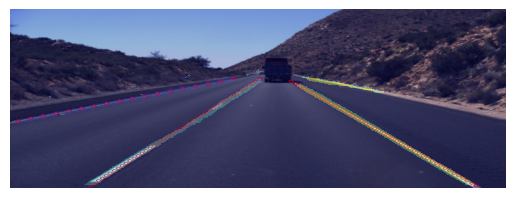

0.988


In [38]:
predict_image(net, acc_enet_sad[-1])

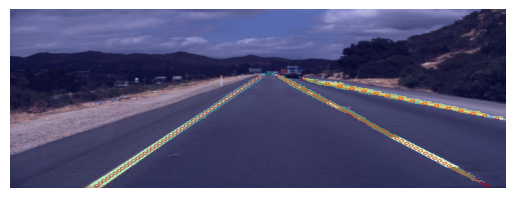

0.982


In [39]:
predict_image(net, acc_enet_sad[-2])

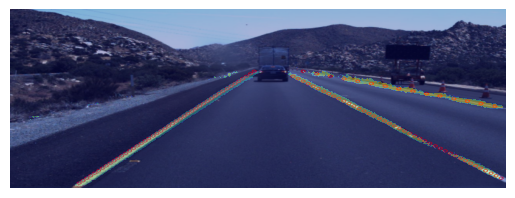

0.982


In [40]:
predict_image(net, acc_enet_sad[-3])

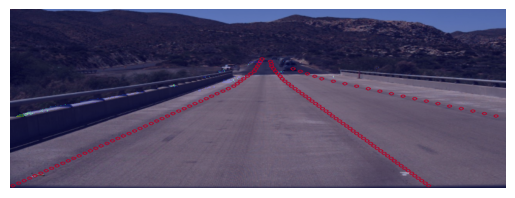

0.268


In [41]:
predict_image(net, acc_enet_sad[0])

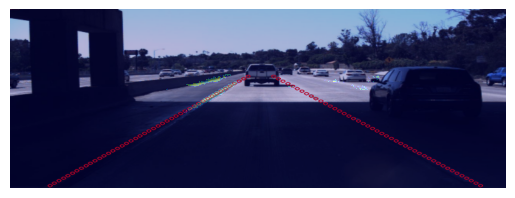

0.321


In [42]:
predict_image(net, acc_enet_sad[1])

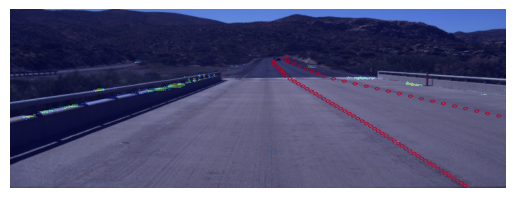

0.321


In [43]:
predict_image(net, acc_enet_sad[2])

In [73]:
import cv2, torch, numpy as np
from torchvision import transforms

def load_model_onnx(path, device):
    # Loads an ONNX model for inference
    import onnxruntime as ort
    providers = ['CUDAExecutionProvider'] if device == 'cuda' else ['CPUExecutionProvider']
    session = ort.InferenceSession(path, providers=providers)
    return session

def process_video(model_path, in_path, out_path, device='cuda', inp_size=(800,288), conf_thresh=0.5, alpha=0.6):
    import onnxruntime as ort

    dev = device
    session = load_model_onnx(model_path, dev)

    cap = cv2.VideoCapture(in_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video {in_path}")

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0

    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((inp_size[1], inp_size[0])),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    print("Processing video...")
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        t = tf(img).unsqueeze(0).numpy()  # convert to NumPy for ONNX runtime

        # Run model
        pred = session.run(None, {'input': t})[0]

        mask = pred.squeeze()
        mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
        mask = cv2.resize(mask, (w, h))
        bin_mask = (mask > conf_thresh).astype(np.uint8) * 255

        color_mask = np.zeros_like(frame)
        color_mask[:, :, 1] = bin_mask
        out_frame = cv2.addWeighted(frame, 1.0, color_mask, alpha, 0)
        out.write(out_frame)

    cap.release()
    out.release()
    print(f"✅ Done! Saved output to: {out_path}")


In [75]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 MB 5.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.2 MB/s eta 0:00:00


In [82]:
# Install ONNX runtime if you haven't already (uncomment & run once)
# !pip install onnxruntime-gpu     # for GPU-enabled runtimes
# !pip install onnxruntime         # for CPU-only

import cv2, numpy as np, onnxruntime as ort
from torchvision import transforms
from PIL import Image
import os

def load_onnx_session(path, device='cuda'):
    # choose providers
    if device == 'cuda':
        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    else:
        providers = ['CPUExecutionProvider']
    sess = ort.InferenceSession(path, providers=providers)
    print("ONNX session created. Providers:", sess.get_providers())
    print("Model inputs:", [(i.name, i.shape, i.type) for i in sess.get_inputs()])
    print("Model outputs:", [(o.name, o.shape, o.type) for o in sess.get_outputs()])
    return sess

def _preprocess_frame(img_bgr, inp_size):
    # img_bgr: HxWx3 BGR from cv2
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(img_rgb)
    pil = pil.resize((inp_size[0], inp_size[1]), Image.BILINEAR)  # inp_size=(W,H)
    t = np.array(pil).astype(np.float32) / 255.0
    # Normalize with ImageNet stats (change if you used different norm)
    mean = np.array([0.485,0.456,0.406], dtype=np.float32)
    std  = np.array([0.229,0.224,0.225], dtype=np.float32)
    t = (t - mean) / std
    # transpose to NCHW
    t = np.transpose(t, (2,0,1))[None, ...].astype(np.float32)
    return t

def _postprocess_output(pred, target_wh):
    # pred: numpy array (anything)
    # target_wh: (W, H) desired output size for cv2.resize
    # Try to reduce to (H, W) single-channel mask
    if isinstance(pred, list) or isinstance(pred, tuple):
        pred = pred[0]
    arr = np.asarray(pred)
    # Remove batch dim if present
    if arr.ndim == 4 and arr.shape[0] == 1:
        arr = arr[0]            # now C,H,W
    # If C,H,W -> pick first channel or argmax
    if arr.ndim == 3:
        c,h,w = arr.shape
        if c == 1:
            arr = arr[0]
        else:
            # assume logits for multiple classes -> take argmax
            arr = np.argmax(arr, axis=0).astype(np.float32)
    # If still scalar or empty, raise
    if arr.size == 0:
        raise ValueError(f"Postprocess found empty array with shape {arr.shape}")
    # Normalize to 0..1
    arr = arr.astype(np.float32)
    mn, mx = arr.min(), arr.max()
    if mx - mn > 1e-6:
        arr = (arr - mn) / (mx - mn)
    else:
        arr = np.zeros_like(arr, dtype=np.float32)
    # resize to target_wh (W,H). cv2.resize wants (W,H) as dsize
    target_w, target_h = int(target_wh[0]), int(target_wh[1])
    arr_resized = cv2.resize(arr, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    return arr_resized

def process_video_onnx(
    model_path,
    in_path,
    out_path,
    device='cuda',
    inp_size=(800,288),   # (W,H) used for resizing model input
    conf_thresh=0.5,
    alpha=0.6,
    debug_one_frame=True
):
    # Load session
    sess = load_onnx_session(model_path, device=device)
    inp_meta = sess.get_inputs()[0]
    inp_name = inp_meta.name

    # open video
    cap = cv2.VideoCapture(in_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video {in_path}")

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    print(f"Video opened: {in_path}  size={w}x{h}  fps={fps}")

    out_dir = os.path.dirname(out_path)
    if out_dir and not os.path.exists(out_dir):
        os.makedirs(out_dir, exist_ok=True)
    writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w,h))

    # read one frame to test inference and inspect output shape
    ret, frame = cap.read()
    if not ret:
        raise RuntimeError("Video contains no frames")
    test_input = _preprocess_frame(frame, inp_size)  # NCHW float32

    # Run a single test inference and display shapes
    try:
        out_vals = sess.run(None, {inp_name: test_input})
    except Exception as e:
        raise RuntimeError(f"ONNX inference failed on a single frame: {e}")

    print("Single-run model outputs count:", len(out_vals))
    for i, o in enumerate(out_vals):
        print(f" output[{i}] shape:", np.asarray(o).shape, " dtype:", np.asarray(o).dtype)

    # Try to postprocess the first output to a mask; if that fails, raise helpful info
    try:
        test_mask = _postprocess_output(out_vals[0], (w,h))
        print("Test mask shape after postprocess:", test_mask.shape)
    except Exception as e:
        # Save debug frame and raise informative error
        debug_path = "/tmp/onnx_debug_frame.jpg"
        cv2.imwrite(debug_path, frame)
        raise RuntimeError(
            f"Could not convert the model output to a valid mask. Error: {e}\n"
            f"I saved one test frame to {debug_path}. Model output shapes: "
            f"{[np.asarray(x).shape for x in out_vals]}. "
            "Common fixes: check your ONNX model output layout (NCHW vs NHWC), "
            "or whether the model returns multiple outputs (choose correct one)."
        )

    # If debug_one_frame, write the test frame's overlay to out and continue; else reset back to start
    mask_vis = (test_mask > conf_thresh).astype(np.uint8) * 255
    color_mask = np.zeros_like(frame)
    color_mask[:,:,1] = mask_vis
    overlay = cv2.addWeighted(frame, 1.0, color_mask, alpha, 0)
    writer.write(overlay)

    # process remaining frames (we already consumed one)
    frame_count = 1
    print("Processing remaining frames...")
    with np.errstate(all='ignore'):
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            try:
                inp = _preprocess_frame(frame, inp_size)
                outs = sess.run(None, {inp_name: inp})
                mask = _postprocess_output(outs[0], (w,h))
            except Exception as e:
                # on error, write original frame and continue, and print a helpful message
                print(f"[Warning] inference/postprocess failed at frame {frame_count}: {e}")
                writer.write(frame)
                frame_count += 1
                continue

            bin_mask = (mask > conf_thresh).astype(np.uint8) * 255
            color_mask = np.zeros_like(frame)
            color_mask[:,:,1] = bin_mask
            out_frame = cv2.addWeighted(frame, 1.0, color_mask, alpha, 0)
            writer.write(out_frame)
            frame_count += 1
            if frame_count % 200 == 0:
                print("Processed", frame_count, "frames...")

    cap.release()
    writer.release()
    print("Done. saved ->", out_path)


# ---------------------------
# Example usage: adjust these paths and run
# ---------------------------
model_path = "/kaggle/working/scnn.onnx"   # your ONNX model
input_video = "/kaggle/input/video-test/test2.mp4"
output_video = "/kaggle/working/output_lane1.mp4"

# Call the function (set device to 'cpu' if CUDA not available)
process_video_onnx(model_path, input_video, output_video, device='cuda', inp_size=(800,288))


ONNX session created. Providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
Model inputs: [('input', ['batch_size', 3, 288, 800], 'tensor(float)')]
Model outputs: [('seg_pred', ['batch_size', 7, 288, 800], 'tensor(float)'), ('1044', ['Sigmoid1044_dim_0', 6], 'tensor(float)'), ('1045', [], 'tensor(float)'), ('1046', [], 'tensor(float)'), ('1047', [], 'tensor(float)')]
Video opened: /kaggle/input/video-test/test2.mp4  size=1280x720  fps=50.0
Single-run model outputs count: 5
 output[0] shape: (1, 7, 288, 800)  dtype: float32
 output[1] shape: (1, 6)  dtype: float32
 output[2] shape: ()  dtype: float32
 output[3] shape: ()  dtype: float32
 output[4] shape: ()  dtype: float32
Test mask shape after postprocess: (720, 1280)
Processing remaining frames...
Processed 200 frames...
Processed 400 frames...
Processed 600 frames...
Processed 800 frames...
Processed 1000 frames...
Processed 1200 frames...
Done. saved -> /kaggle/working/output_lane.mp4
